## Delhi House Price Prediction Project

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
# Reading the dataset
df=pd.read_csv(r"C:\Users\sharm\Downloads\DelhiHousePrice.csv")
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


# Understanding Dataset

In [3]:
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [4]:
df.tail()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0
1258,11050.0,3,3.0,Unfurnished,Chittaranjan Park,1.0,18500000,Ready_to_move,New_Property,Builder_Floor,12916.0


In [5]:
df.shape

(1259, 11)

In [6]:
df.size

13849

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   object 
 4   Locality     1259 non-null   object 
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   object 
 8   Transaction  1259 non-null   object 
 9   Type         1254 non-null   object 
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), object(5)
memory usage: 108.3+ KB


In [8]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1257.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.556086,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.042220,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


## Data Cleaning

In [9]:
df.isna().sum()

Area             0
BHK              0
Bathroom         2
Furnishing       5
Locality         0
Parking         33
Price            0
Status           0
Transaction      0
Type             5
Per_Sqft       241
dtype: int64

In [10]:
# Replacing missing values
df = df.replace(r'^\s*$', np.nan, regex=True)

In [11]:
# Handle missing values
df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median())
df['Parking'] = df['Parking'].fillna(df['Parking'].median())
df['Per_Sqft'] = df['Per_Sqft'].fillna(df['Per_Sqft'].median())

df['Furnishing'] = df['Furnishing'].fillna(df['Furnishing'].mode()[0])
df['Type'] = df['Type'].fillna(df['Type'].mode()[0])

In [12]:
df.isna().sum()

Area           0
BHK            0
Bathroom       0
Furnishing     0
Locality       0
Parking        0
Price          0
Status         0
Transaction    0
Type           0
Per_Sqft       0
dtype: int64

## Encoding

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

## Exploratory Data Analysis (EDA)

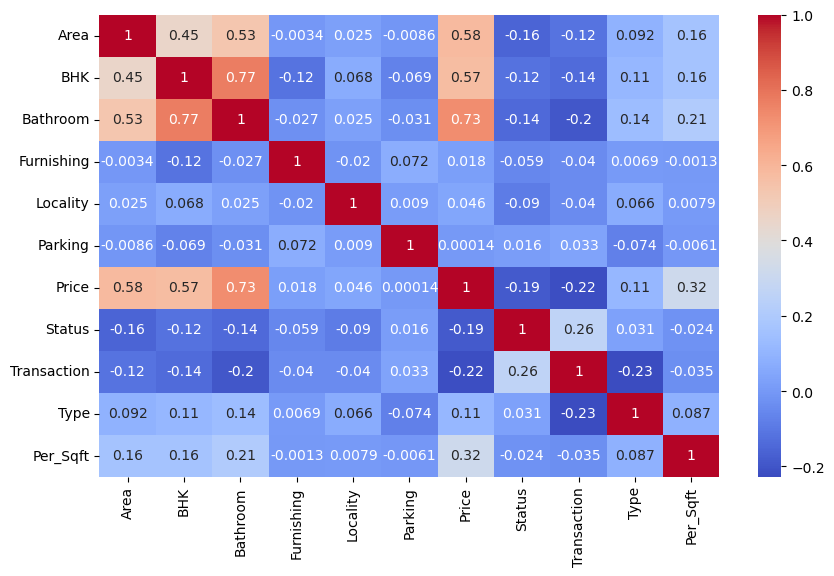

In [14]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

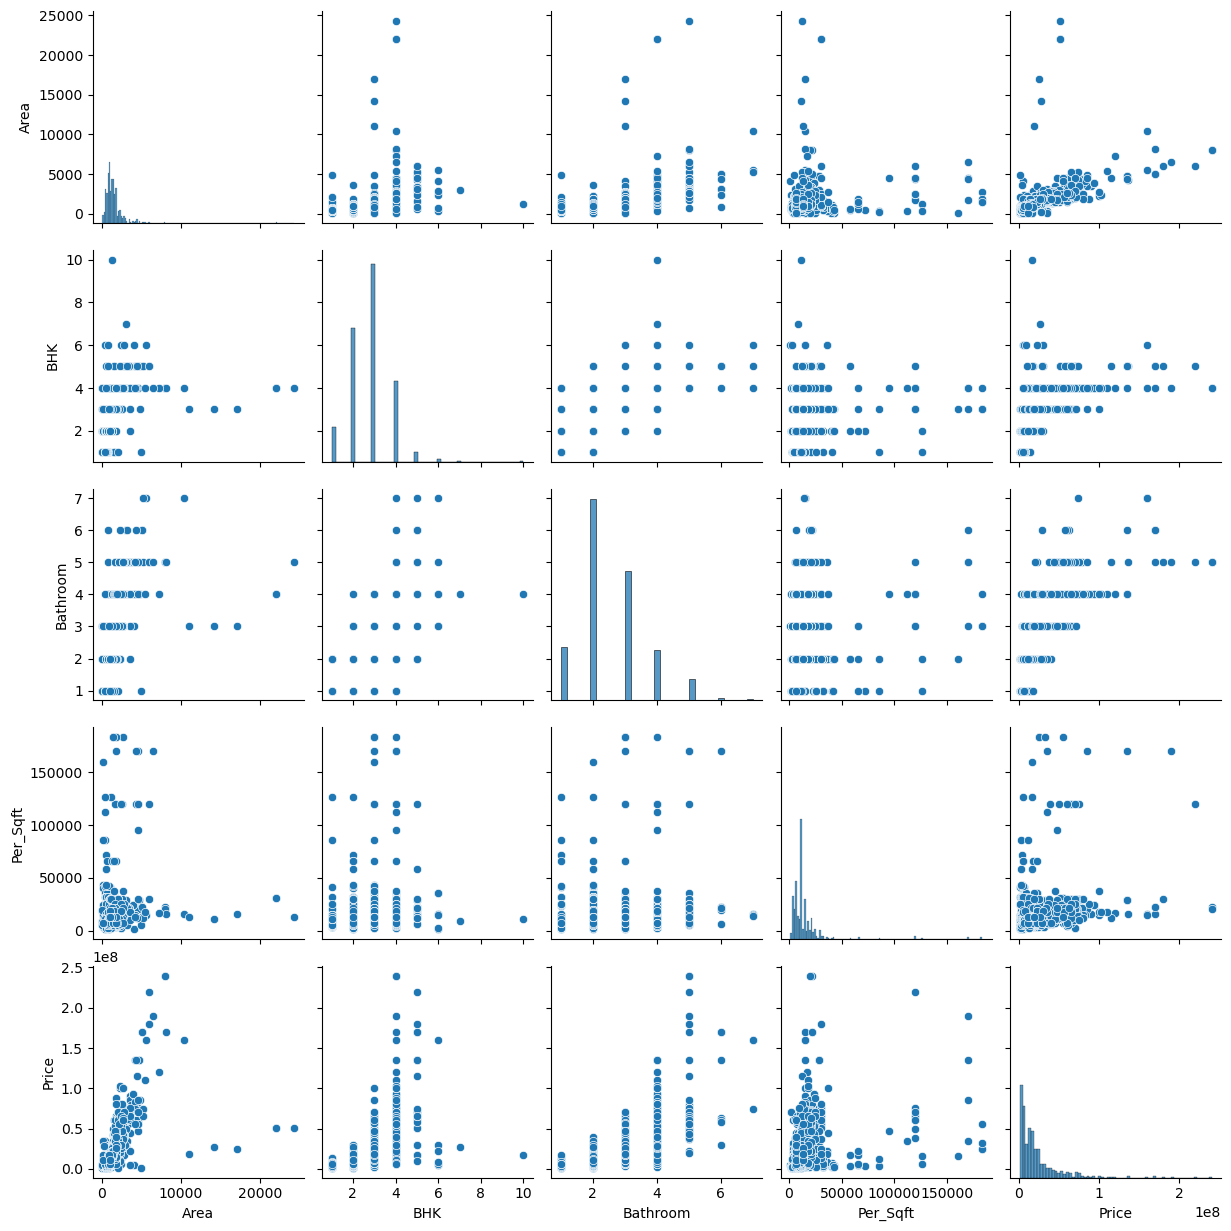

In [15]:
# Pairplot (optional)
cols = ['Area', 'BHK', 'Bathroom', 'Per_Sqft', 'Price']
sns.pairplot(df[cols])
plt.show()

## Feature Selection

In [16]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [17]:
print(df.columns)

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Locality', 'Parking', 'Price',
       'Status', 'Transaction', 'Type', 'Per_Sqft'],
      dtype='object')


## Train-Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
X_test

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Status,Transaction,Type,Per_Sqft
76,1620.0,3,2.0,1,52,1.0,1,1,0,3524.0
1026,1775.0,3,3.0,1,336,1.0,0,0,0,14366.0
43,1130.0,2,2.0,2,171,1.0,1,1,1,11291.5
666,2500.0,4,4.0,1,249,2.0,1,1,0,21000.0
529,50.0,2,1.0,1,314,1.0,1,0,0,6667.0
...,...,...,...,...,...,...,...,...,...,...
430,100.0,3,2.0,1,240,2.0,1,1,0,160000.0
32,900.0,2,2.0,2,167,1.0,1,0,1,11291.5
156,450.0,1,1.0,0,34,1.0,1,1,1,4444.0
376,500.0,2,1.0,1,173,1.0,1,1,1,32000.0


In [20]:
y_test

76      14900000
1026    25500000
43       7800000
666     52500000
529      1950000
          ...   
430     16000000
32      10500000
156      2000000
376      3700000
620      6300000
Name: Price, Length: 252, dtype: int64

In [21]:
X_train

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Status,Transaction,Type,Per_Sqft
243,4300.0,4,4.0,2,221,2.0,1,1,1,120000.0
514,504.0,3,1.0,1,309,1.0,1,1,0,7143.0
966,1000.0,3,2.0,0,107,2.0,1,1,0,11291.5
199,1295.0,3,2.0,1,139,1.0,1,0,0,6875.0
270,2650.0,4,4.0,2,146,2.0,1,0,1,11291.5
...,...,...,...,...,...,...,...,...,...,...
1044,1200.0,3,2.0,1,153,1.0,1,1,1,7290.0
1095,1350.0,3,3.0,2,316,2.0,1,1,0,12307.0
1130,1000.0,2,2.0,1,255,1.0,1,1,0,7800.0
860,565.0,2,2.0,2,182,1.0,1,1,1,5820.0


In [22]:
y_train

243      60000000
514       3600000
966      12000000
199      10000000
270      75000000
          ...    
1044     14500000
1095     20000000
1130      7800000
860       3500000
1126    115000000
Name: Price, Length: 1007, dtype: int64

## Model Training

In [23]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [24]:
#Random Forest (Better)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

## Evaluation

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("R2:", r2_score(y_test, lr_pred))

print("\nRandom Forest:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("R2:", r2_score(y_test, rf_pred))

Linear Regression:
MAE: 10240096.444309283
R2: 0.5915349103780592

Random Forest:
MAE: 5915549.007936508
R2: 0.8236438088099085


## Save Model

In [26]:
import pickle

# save model
pickle.dump(rf, open("model.pkl", "wb"))

In [27]:
pickle.dump({
    "model": rf,
}, open("model.pkl", "wb"))
print("pkl file created")

pkl file created


## Streamlit Development

In [28]:
import streamlit as st
import pandas as pd
import pickle

# Load model
data = pickle.load(open("model.pkl", "rb"))
model = data["model"]

st.title("🏠 Delhi House Price Prediction")

# Inputs
area = st.number_input("Area (sq ft)")
bhk = st.number_input("BHK")
bathroom = st.number_input("Bathrooms")
parking = st.number_input("Parking")

# Predict
if st.button("Predict Price"):
    input_data = pd.DataFrame([[area, bhk, bathroom, parking]],
                             columns=["Area","BHK","Bathroom","Parking"])
    
    prediction = model.predict(input_data)
    
    st.success(f"💰 Estimated Price: {prediction[0]:.2f}")

2026-04-24 09:19:54.357 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 09:19:55.625 
  command:

    streamlit run C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-24 09:19:55.627 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 09:19:55.628 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 09:19:55.630 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 09:19:55.630 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 09:19:55.631 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 09:19:55.632 Session state does not 